# TyreVisionX: Professor Meeting Overview

## 1. Title and Purpose
TyreVisionX is an early-stage academic research prototype for tyre defect inspection. The current repository supports supervised binary classification of tyre images and the surrounding research workflow: dataset manifests, training, evaluation, error analysis, and reporting.

### Why this problem matters in industry
Tyre inspection matters because defects can lead to safety risks, wasted production output, or costly downstream handling. In practical inspection settings, missed defects are usually more serious than extra false alarms.

### Why this is early-stage but promising
This project is still at the research prototype stage. It already has a cleaner canonical pipeline, historical baseline results, and real evaluation artifacts, but it does not yet have broad multi-dataset validation, localization, segmentation, or deployment-grade maturity.

In [1]:
from pathlib import Path
import json
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from IPython.display import display, Markdown

def find_repo_root(start: Path | None = None) -> Path:
    current = (start or Path.cwd()).resolve()
    for candidate in [current, *current.parents]:
        if (candidate / 'pyproject.toml').exists() and (candidate / 'src').exists():
            return candidate
    raise FileNotFoundError('Could not locate the TyreVisionX repo root from the current working directory.')

repo_root = find_repo_root()
print('Repo root:', repo_root)

best_day3_dir = repo_root / 'artifacts/day3_baseline/frozen_resnet50_unfreeze_v2_3ep'
best_day3_report_path = best_day3_dir / 'eval_report.json'
day5_summary_path = repo_root / 'artifacts/day5/longrun_seed_sweep/summary_by_model.csv'
day5_short_path = repo_root / 'artifacts/day5/step3_step4_comparison.csv'

best_day3_report = json.loads(best_day3_report_path.read_text(encoding='utf-8')) if best_day3_report_path.exists() else None
day5_summary_df = pd.read_csv(day5_summary_path) if day5_summary_path.exists() else pd.DataFrame()
day5_short_df = pd.read_csv(day5_short_path) if day5_short_path.exists() else pd.DataFrame()

Repo root: /Users/ritik/Documents/Project TDA/TyreVisionX


## 2. Project Vision
### Simple English first
The long-term vision of TyreVisionX is to move from simple image classification toward a more complete tyre-inspection research system.

That long-term direction includes:
- tyre defect detection from images
- learning under limited data
- anomaly detection for unseen defect patterns
- future localization and segmentation
- future multi-view 3D reconstruction
- future projection of defect evidence onto a 3D tyre surface
- future knowledge-driven reasoning about defect causes

### Technical detail
Right now, only the binary classification part is validated in the repository. The other parts are best understood as future research directions, not completed deliverables.

## 3. Problem Statement
TyreVisionX is trying to solve the problem of identifying defective tyres from image data in a way that can eventually support robust industrial inspection.

### Why tyre inspection is challenging
- defects may be subtle
- appearance can vary with lighting, angle, and texture
- false negatives matter more than many false positives
- data is limited and not yet broad enough for strong generalization claims

### Why limited data is the current bottleneck
The repository currently has one populated tracked manifest for D1, while D2 and D3 remain configured but not populated in tracked manifests. That means the strongest current evidence is still narrow rather than broad.

### Why this is a research problem, not just a coding task
The main difficulty is not writing training code. The real difficulty is designing a meaningful experimental program around limited data, reliable metrics, generalization, and future extensions such as anomaly detection and localization.

## 4. Current Project Stage
The repository now has one clear canonical path and one archived legacy path. The table below summarizes the current stage honestly.

In [2]:
stage_df = pd.DataFrame([
    {'Area': 'Canonical pipeline', 'Status': 'Implemented now', 'Notes': 'Config-driven training and evaluation via src/train.py and src/evaluate.py'},
    {'Area': 'D1 classification', 'Status': 'Implemented now', 'Notes': 'Tracked manifest exists and historical evaluation artifacts are available'},
    {'Area': 'FastAPI / Streamlit utilities', 'Status': 'Implemented now', 'Notes': 'Utility surfaces exist, but depend on available trained artifacts'},
    {'Area': 'D2 / D3 support', 'Status': 'Partially implemented', 'Notes': 'Configured in YAML, but tracked manifests are empty'},
    {'Area': 'CNN→GNN path', 'Status': 'Experimental', 'Notes': 'Optional code path, not yet validated by tracked experiments'},
    {'Area': 'Localization / segmentation', 'Status': 'Planned', 'Notes': 'Roadmap direction only'},
    {'Area': 'Multi-view 3D / mesh projection / knowledge reasoning', 'Status': 'Future work', 'Notes': 'Long-term vision, not implemented now'},
])
display(stage_df)

,Area,Status,Notes
0,Canonical pipeline,Implemented now,Config-driven training and evaluation via src/...
1,D1 classification,Implemented now,Tracked manifest exists and historical evaluat...
2,FastAPI / Streamlit utilities,Implemented now,"Utility surfaces exist, but depend on availabl..."
3,D2 / D3 support,Partially implemented,"Configured in YAML, but tracked manifests are ..."
4,CNN→GNN path,Experimental,"Optional code path, not yet validated by track..."
5,Localization / segmentation,Planned,Roadmap direction only
6,Multi-view 3D / mesh projection / knowledge re...,Future work,"Long-term vision, not implemented now"


## 5. Tech Stack and Tools Used
| Tool | Simple English | How It Is Used Here | Why It Was Chosen |
| --- | --- | --- | --- |
| Python | Main programming language | All training, evaluation, scripts, and notebooks | Flexible and standard for ML research |
| PyTorch | Deep learning framework | Training and inference for CNN / ResNet models | Research-friendly and widely used |
| torchvision | Vision model and transform support | ResNet backbones and image-model utilities | Natural fit with PyTorch vision workflows |
| albumentations | Image augmentation library | Training and eval transform pipelines | Strong augmentation support and readable config style |
| OpenCV | Image reading and processing | Dataset loading and some visualization utilities | Fast and common in computer vision pipelines |
| FastAPI | Web API framework | Inference service endpoint | Lightweight and clean for demo serving |
| Streamlit | Quick UI framework | Interactive QA app | Useful for simple research demos |
| ONNX / TorchScript | Model export formats | Export path in `src/export.py` | Useful for future portability and deployment experiments |
| YAML configs | Human-readable config files | Dataset, augmentation, and train configs | Improves reproducibility and clarity |
| Notebooks / reports / logs | Research communication layer | Professor-facing explanation, status tracking, experiment summaries | Important for honest, discussion-ready research work |

## 6. ML / CV Concepts Used So Far

### CNN
Plain English: a CNN learns visual patterns from images.

Project-specific usage: CNNs are the core model family for tyre image classification in this repository.

### Convolution
Plain English: a small learned filter slides across the image and looks for useful local patterns.

Project-specific usage: useful for grooves, cracks, edges, and texture disruptions on tyre surfaces.

### Feature maps
Plain English: internal visual summaries produced by the network.

Project-specific usage: the baseline CNN and ResNet models both convert raw image pixels into progressively more abstract feature maps.

### Transfer learning
Plain English: start from a model that already knows general image features.

Project-specific usage: the active ResNet path uses pretrained backbones to make better use of limited data.

### ResNet
Plain English: a stronger CNN design with skip connections.

Project-specific usage: ResNet-18 and ResNet-34 are the canonical current models.

### Augmentation
Plain English: create controlled variations of training images.

Project-specific usage: used to improve robustness to lighting, crop, and viewpoint variation.

### Train / validation / test split
Plain English: separate data for learning, tuning, and checking final performance.

Project-specific usage: manifests include split assignments and the pipeline preserves them.

### Overfitting
Plain English: a model learns the training examples too specifically.

Project-specific usage: an important risk because the repository still operates in a limited-data setting.

### Generalization
Plain English: performance on new data, not just familiar data.

Project-specific usage: currently more of a research goal than a fully validated result, because D2 and D3 are not yet populated in tracked manifests.

### Class imbalance
Plain English: one class appears more often than another.

Project-specific usage: D1 is near-balanced, but defect recall still matters more than raw accuracy.

### Confusion matrix
Plain English: shows counts of correct and incorrect predictions by class.

Project-specific usage: very useful because false negatives are high-cost in inspection.

### Precision, Recall, F1
Plain English: precision measures false alarms, recall measures missed positives, and F1 balances both.

Project-specific usage: defect recall and defect F1 are central metrics in this project.

### AUROC / PR curve
Plain English: these summarize ranking quality across decision thresholds.

Project-specific usage: they help judge whether the model separates defect and good cases well even before threshold tuning.

### Threshold tuning
Plain English: choose a cutoff that matches the real inspection goal.

Project-specific usage: repeatedly mentioned in historical reports as important for recall-critical use, but not yet a completed canonical study.

## 7. Repository Architecture and Workflow
### Workflow from data to prediction

```text
Dataset folders
    -> manifest generation (`scripts/prepare_manifests.py`)
    -> split management (`scripts/prepare_folds.py`)
    -> config-driven dataset loading (`src/data/datasets.py`)
    -> preprocessing / transforms (`src/data/transforms.py`)
    -> model training (`src/train.py`)
    -> evaluation and report generation (`src/evaluate.py`)
    -> analysis via notebooks / reports / logs
    -> optional export / serving / demo (`src/export.py`, `src/service_fastapi.py`, `src/app_streamlit.py`)
```

### Why this matters
The cleaned repository now makes the active path much easier to explain. It is still an early-stage research pipeline, but it is no longer as ambiguous as before the cleanup.

## 8. Models Used in the Project
### SimpleCNN
- what it is: a small CNN baseline
- relevance: useful for fast experiments and low-complexity comparisons
- strengths: lightweight, easy to reason about
- limitations: weaker representation capacity and poorer stability than stronger transfer-learning models
- repo role: historical baseline, now archived under the legacy path

### ResNet-based transfer learning models
- what they are: stronger CNN backbones pretrained on ImageNet
- relevance: better suited to limited-data classification than training everything from scratch
- strengths: better feature reuse, stronger documented historical results in this repo
- limitations: still only validated primarily on D1 in tracked repo evidence
- repo role: core current model family

### Optional CNN→GNN component
- what it is: an experimental extension that reasons over relationships between learned regions
- relevance: potentially useful for richer spatial reasoning in future work
- strengths: academically interesting direction
- limitations: not yet validated by tracked experiments here
- repo role: experimental / future-facing

## 9. Results So Far
This section uses only real tracked artifacts already present in the repository. The strongest current evidence is still historical baseline evidence rather than fresh outputs from the cleaned canonical pipeline.

In [3]:
if best_day3_report is not None:
    m = best_day3_report['metrics']
    day3_best_df = pd.DataFrame([
        {
            'Run': 'frozen_resnet50_unfreeze_v2_3ep',
            'Split': best_day3_report.get('split'),
            'Accuracy': m.get('accuracy'),
            'Defect Recall': m.get('recall_defect'),
            'Defect F1': m.get('f1_defect'),
            'AUROC': m.get('auroc'),
            'AUPRC': m.get('auprc'),
            'Confusion': str(m.get('confusion')),
        }
    ])
    display(Markdown('### Historical Day 3 baseline result used for discussion'))
    display(day3_best_df)
else:
    display(Markdown('### Historical Day 3 baseline result used for discussion\nPending: tracked report not found.'))

display(Markdown('### Day 5 long-run multi-seed summary'))
if not day5_summary_df.empty:
    display(day5_summary_df)
else:
    display(Markdown('Pending: `artifacts/day5/longrun_seed_sweep/summary_by_model.csv` not found.'))

display(Markdown('### Day 5 short-run comparison'))
if not day5_short_df.empty:
    display(day5_short_df)
else:
    display(Markdown('Pending: `artifacts/day5/step3_step4_comparison.csv` not found.'))

### Historical Day 3 baseline result used for discussion

,Run,Split,Accuracy,Defect Recall,Defect F1,AUROC,AUPRC,Confusion
0,frozen_resnet50_unfreeze_v2_3ep,test,0.980392,0.969231,0.980545,0.998523,0.998585,"[[124, 1], [4, 126]]"


### Day 5 long-run multi-seed summary

,model_key,model,recall_mean,recall_std,precision_mean,precision_std,fn_mean,fn_std,fp_mean,fp_std,auprc_mean,auprc_std
0,baseline,Baseline,0.943590,0.084382,0.745787,0.053339,7.333333,10.969655,43.000000,14.730920,0.901674,0.011379
1,augmentation,+ Augmentation,0.941026,0.029123,0.778739,0.030068,7.666667,3.785939,35.000000,7.000000,0.946823,0.007912
2,dropout,+ Dropout,0.894872,0.108876,0.737010,0.072134,13.666667,14.153916,43.666667,18.929694,0.887496,0.015746
3,batchnorm,+ BatchNorm,0.864103,0.103870,0.765983,0.130173,17.666667,13.503086,39.000000,28.513155,0.887344,0.047774


### Day 5 short-run comparison

,Model,Recall,Precision,FN count,FP count,F1,Accuracy,AUROC,AUPRC,Run Dir
0,Baseline,0.992308,0.724719,1,49,0.837662,0.803922,0.934092,0.923418,artifacts/day5/step3_step4_baseline
1,+ Augmentation,0.984615,0.766467,2,39,0.861953,0.839216,0.932677,0.920072,artifacts/day5/step3_step4_aug
2,+ BatchNorm,0.907692,0.732919,12,43,0.810997,0.784314,0.864985,0.844552,artifacts/day5/step3_step4_aug_batchnorm_fix
3,+ Dropout,0.953846,0.639175,6,70,0.765432,0.701961,0.821415,0.811689,artifacts/day5/step3_step4_aug_batchnorm_dropo...


### Interpretation of the current results
- The historical ResNet transfer-learning path shows very strong D1 performance.
- The Day 5 baseline study suggests augmentation improves stability and precision / AUPRC trade-off.
- These results are promising, but they are still limited in scope and should not be treated as proof of broad generalization.
- Fresh canonical-pipeline outputs under `artifacts/experiments/` are still pending.

### To be generated in future experiments
- fresh canonical D1 result after cleanup
- D2 / D3 cross-dataset evaluation
- threshold-calibrated recall operating points under the canonical path
- localization or segmentation outputs

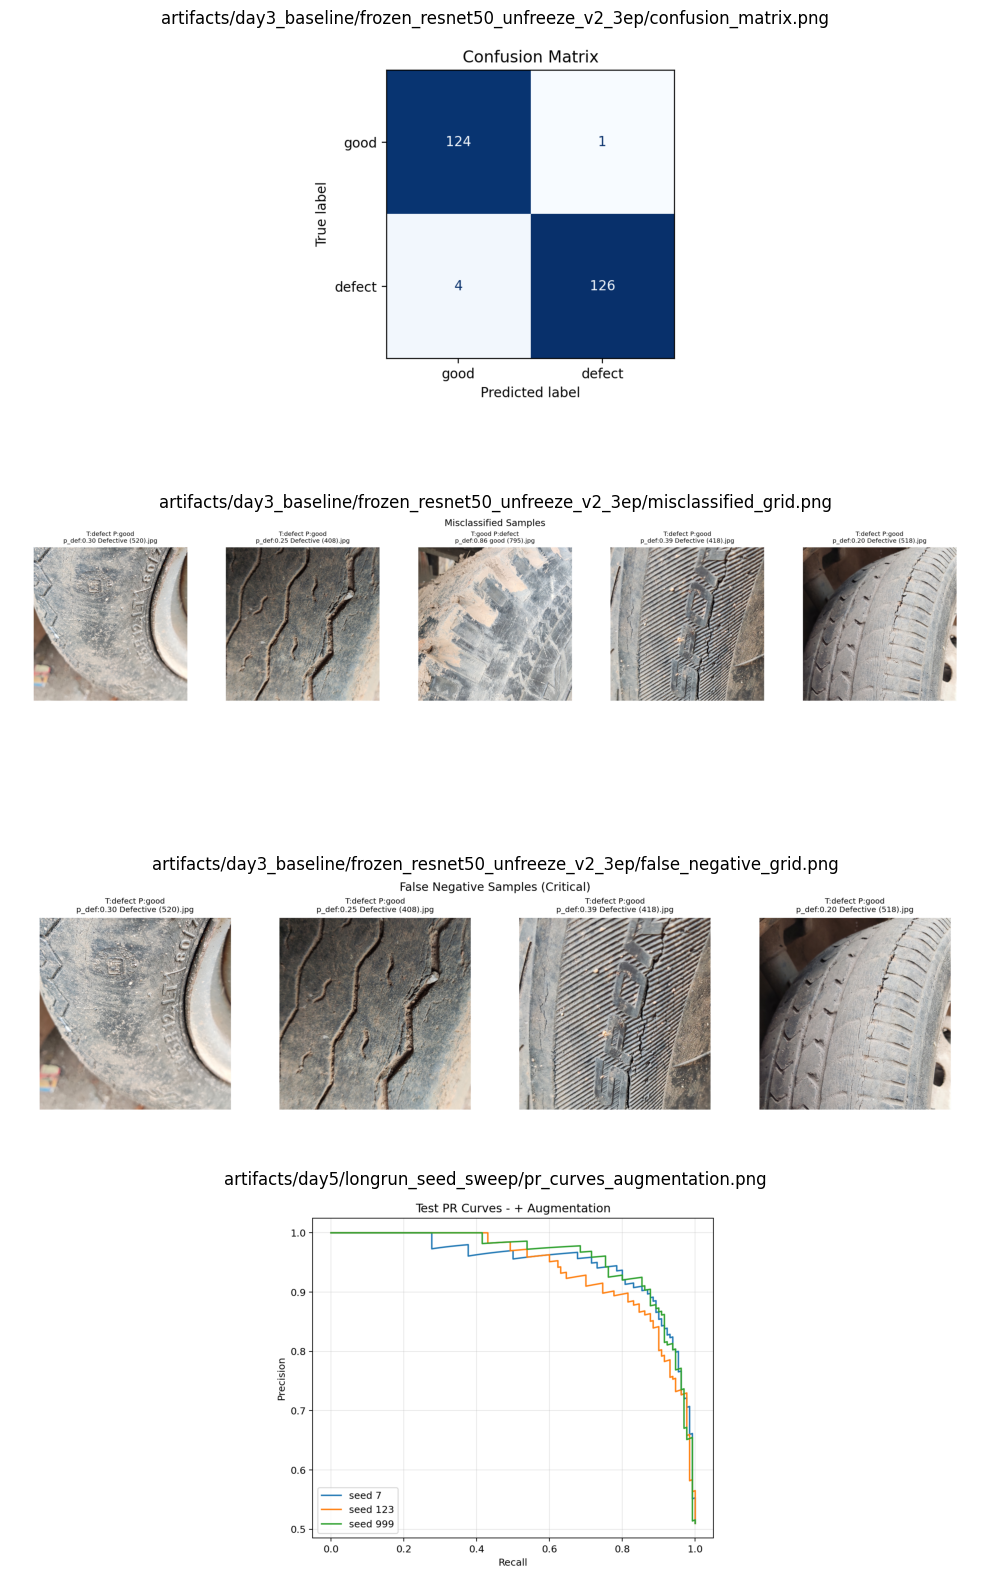

In [4]:
image_candidates = [
    repo_root / 'artifacts/day3_baseline/frozen_resnet50_unfreeze_v2_3ep/confusion_matrix.png',
    repo_root / 'artifacts/day3_baseline/frozen_resnet50_unfreeze_v2_3ep/misclassified_grid.png',
    repo_root / 'artifacts/day3_baseline/frozen_resnet50_unfreeze_v2_3ep/false_negative_grid.png',
    repo_root / 'artifacts/day5/longrun_seed_sweep/pr_curves_augmentation.png',
]

existing = [p for p in image_candidates if p.exists()]
if not existing:
    display(Markdown('No tracked result images were found for inline display.'))
else:
    fig, axes = plt.subplots(len(existing), 1, figsize=(10, 4 * len(existing)))
    if len(existing) == 1:
        axes = [axes]
    for ax, path in zip(axes, existing):
        img = Image.open(path)
        ax.imshow(img)
        ax.set_title(path.relative_to(repo_root))
        ax.axis('off')
    plt.tight_layout()
    plt.show()

## 10. Progress Till Now
### Research progress story
1. Initial dataset preparation and manifest workflow were established.
2. A baseline CNN path was built for early experimentation.
3. Transfer-learning baselines with ResNet improved the quality of available results.
4. Evaluation artifacts such as confusion matrices and misclassification exports were added.
5. Day 5 work expanded the baseline story into regularization, augmentation, and stability comparisons.
6. The repository was then cleaned to make one canonical path obvious and to separate legacy code from active code.
7. Research-facing logs, notebooks, and status reports were added for honest professor discussion.

This is better understood as research workflow progress rather than just software refactoring progress.

## 11. Difficulties Faced
- **Small data setting**: limited tracked data breadth restricts confidence in generalization.
- **Overfitting risk**: strong image models can look excellent on narrow distributions without broad robustness.
- **Legacy vs new pipeline overlap**: the repository historically contained multiple paths that were not equally current.
- **Path and config inconsistency**: manifests and configs previously pointed to different conventions.
- **Incomplete validation**: D2 and D3 support is still structural more than experimental.
- **Roadmap-level components**: anomaly detection, localization, segmentation, multi-view 3D, and reasoning are still future-facing.

These matter scientifically because they affect the credibility of claims about reliability, robustness, and future research direction.

## 12. Future Implementations

### High priority
| Item | Why it matters | What it requires | Near-term feasibility |
| --- | --- | --- | --- |
| Stronger experiment discipline on the canonical path | Needed to turn cleanup into research evidence | Fresh runs, saved reports, reproducible tracking | High |
| Limited-data generalization study | Central research question for this dataset setting | Better evaluation framing and possibly stronger augmentation / calibration studies | High |
| Cross-dataset evaluation | Needed for robustness claims | Populated D2/D3 manifests and consistent evaluation protocol | Medium to high if data is available |

### Medium priority
| Item | Why it matters | What it requires | Near-term feasibility |
| --- | --- | --- | --- |
| Anomaly detection | Useful for unseen defect patterns | Different modeling and evaluation strategy | Medium |
| Defect localization / detection | Improves interpretability and industrial usefulness | Spatial labels or detection-ready data | Medium |
| Segmentation | Gives precise spatial defect extent | Pixel-level annotation and a new model/data pipeline | Medium to low |

### Later priority
| Item | Why it matters | What it requires | Near-term feasibility |
| --- | --- | --- | --- |
| Multi-view 3D | Strong long-term inspection vision | Multi-view datasets and geometry-aware methods | Low |
| Defect projection to 3D mesh | Better physical interpretability | 3D reconstruction plus defect localization | Low |
| Knowledge graph / reasoning | Could connect defects to causes and decisions | Structured ontology and reasoning framework | Low |

## 13. How Faculty Guidance Can Shape TyreVisionX
Faculty guidance can help this project most by shaping its research direction rather than only its implementation details.

Concrete ways a professor or research group can help:
- refine the problem formulation into a publishable scope
- define what counts as a meaningful next milestone
- suggest benchmark protocols or evaluation priorities
- improve experimental design and avoid weak claims
- point the project toward the most relevant literature
- help prioritize anomaly detection vs robustness vs localization vs 3D directions
- identify what would matter for an industry-facing research outcome
- help convert a good prototype into a stronger academic contribution

This is a collaborative framing: the codebase is now clearer, but the next valuable step depends heavily on research judgment.

## 14. Meeting Talking Points

### What I should say in 1 minute
TyreVisionX is an early-stage research prototype for tyre defect inspection. I have cleaned the repository, clarified the canonical classification pipeline, and preserved the historical baseline path. The strongest current evidence is still from historical D1 baseline experiments, and I now need guidance on the best next research direction: deeper canonical validation, cross-dataset robustness, anomaly detection, or early localization.

### What I should say in 3 minutes
The project currently focuses on binary classification of tyre images into good vs defect. The repo now has one clean active path based on config-driven ResNet models and one archived baseline path. D1 is the only populated tracked dataset manifest, so current claims should stay narrow and honest. Historical results are promising, especially transfer-learning baselines and Day 5 stability studies, but the next important milestone is to turn the cleaned pipeline into fresh reproducible evidence and choose the most meaningful next branch of research.

### Key questions to ask the professor
- Should the next milestone focus on a strong canonical D1 result, or on cross-dataset robustness?
- Is binary classification alone a sufficient near-term research scope, or should I branch earlier into anomaly detection or localization?
- Which metric should drive the next phase: defect recall, defect F1, threshold-calibrated performance, or generalization?
- Which future direction is most academically valuable here: robustness, anomaly detection, localization, or 3D / reasoning work?

### Likely professor questions and short answer ideas
- **What is actually working now?**
  The binary classification pipeline, evaluation flow, and research reporting stack are working. Historical baselines are well documented.
- **What is not yet validated?**
  Cross-dataset robustness, anomaly detection, localization, segmentation, 3D, and knowledge reasoning.
- **What is the biggest current bottleneck?**
  Limited validated data breadth and the absence of fresh canonical experiment outputs after the cleanup.
- **Why is this still promising?**
  Because the baseline evidence is strong enough to justify deeper research, and the repository is now in a cleaner state for that work.

## 15. Closing Summary
TyreVisionX now stands as a cleaner, more honest, early-stage research prototype centered on binary tyre defect classification. It is promising because it already has useful baseline evidence, a clearer canonical pipeline, and a realistic roadmap into stronger research questions such as limited-data generalization, anomaly detection, and localization.

### Next concrete research step
The most important next step is to run and document one fresh canonical-pipeline experiment under the cleaned structure, then use that result to decide whether the project should deepen classification rigor or branch into robustness and beyond-classification research directions.